# 03 · Regresión para demanda: estimar, diagnosticar, regularizar y usar

**Edición docente · 8 de octubre de 2026 · Modelos Predictivos en Negocios**

**Unidad 2 · Semanas 4 y 6 · RA2 (CE 2.3–2.6)**
Construirás una regresión múltiple para QuillayMarket, interpretarás coeficientes con su incertidumbre, modelarás estacionalidad, compararás Ridge, Lasso y árboles, y entregarás predicciones de escenarios con intervalo.

**Cómo trabajar:** ejecuta desde la primera celda. Antes de mover un control, escribe qué esperas que ocurra;
después compara y justifica la diferencia. Los casos son docentes: FinCordillera, QuillayMarket y PulpaLenga son
empresas ficticias con datos simulados del repositorio; las simulaciones adicionales se identifican como tales.

Los controles requieren JupyterLab con `ipywidgets` y un kernel activo; las salidas guardadas permiten leer los
resultados sin ejecutar. Cada función interactiva también puede llamarse directamente con argumentos.

[Guía maestra](../guia_maestra_mpn.html) · [Manual científico](../material_propio/MPN_manual_cientifico.pdf) ·
[Cobertura curricular](../COBERTURA.md)

### Antes de ejecutar

Núcleo · 180 min guiados + 60 min autónomos orientativos.

**Objetivo:** Comparar regresión y alternativas con referencia e incertidumbre de predicción.

**Preparación:** Módulos 01–02; coeficientes y errores de regresión.

**Ejemplo de referencia:** QuillayMarket: comparar mes numérico con codificación por categoría y revisar residuos.

**Práctica:** Modificar un escenario de precio; identificar extrapolación y límites del intervalo.

**Criterio de logro:** Reportar MAE/RMSE, referencia, diagnóstico y diferencia entre IC de media e intervalo predictivo.

**Distribución orientativa:** explicación 45 min; práctica guiada 135 min; trabajo autónomo 60 min. Ajustar tras una clase piloto.

[Guía y secuencia](../guia_maestra_mpn.html#ruta-aprendizaje) · [Fundamento del manual](../material_propio/MPN_manual_cientifico.html#sec-regresion)

In [1]:
from pathlib import Path
import sys
import warnings

RAIZ = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "_transversal" / "datos").is_dir()), None
)
if RAIZ is None:
    raise FileNotFoundError("Abra Jupyter desde el repositorio completo o una subcarpeta.")
CURSO = RAIZ / "03_Modelos_Predictivos_Negocios"
sys.path.insert(0, str(CURSO / "reproducibilidad"))
import mpn_recursos as mr
from mpn_recursos import pregunta, SEMILLA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown

%matplotlib inline
plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.18,
        "font.size": 10,
    }
)
pd.set_option("display.max_columns", 16)
pd.set_option(
    "display.float_format",
    lambda v: f"{v:,.0f}" if abs(v) >= 1e4 or float(v).is_integer() else f"{v:,.3f}",
)
print(f"Python {sys.version.split()[0]} · pandas {pd.__version__} · semilla {SEMILLA}")

Python 3.12.13 · pandas 3.0.6 · semilla 2026


<a id="caso-demanda"></a>

## Caso QuillayMarket: unidad de predicción y exploración

Cada fila es una **réplica simulada de una categoría en un mes** con su precio promedio, promoción, inversión en marketing y unidades
vendidas (480 registros simulados). La decisión que apoya el modelo es cuánto inventario comprar. La métrica guía
es el error absoluto en unidades (MAE) y el sesgo: comprar sistemáticamente de menos o de más tiene costos distintos.

Hay diez réplicas independientes por categoría y mes: no se registran tienda ni año y no es un panel.
La partición aleatoria evalúa escenarios intercambiables de este simulador, no el futuro de una tienda real.
Reservamos desde el inicio 60% para ajuste, 10% para selección, 10% para calibración de intervalos y 20% para prueba.
La calibración no participa en gráficos de selección, ingeniería de variables ni búsqueda de hiperparámetros.


,registro_id,mes,categoria_producto,precio_promedio_clp,promocion_activa,inversion_marketing_clp,ventas_unidades
0,1,11,Vestuario,15000,0,573000,211
1,2,3,Tecnologia,18200,1,823000,247
2,3,2,Electrohogar,18500,0,123000,89
3,4,4,Vestuario,15200,1,682000,200
4,5,10,Electrohogar,18600,1,449000,172


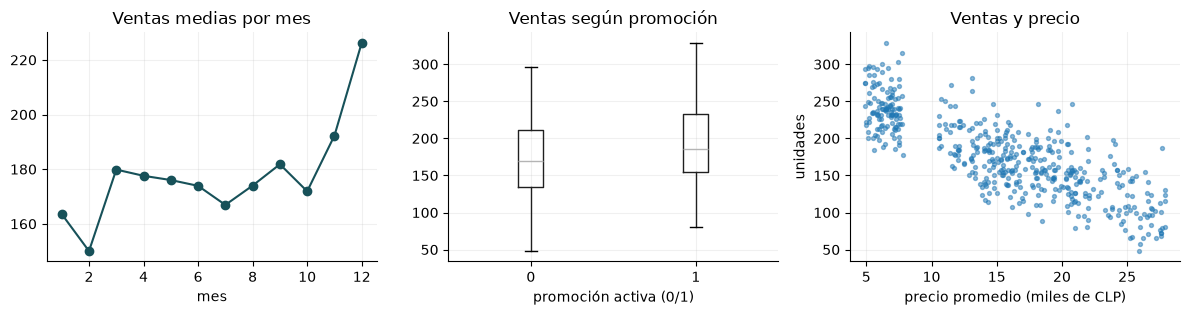

In [2]:
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning

demanda = mr.quillaymarket_demanda()
display(demanda.head())
fig, ejes = plt.subplots(1, 3, figsize=(12, 3.4))
demanda.groupby("mes")["ventas_unidades"].mean().plot(
    ax=ejes[0], marker="o", color="#175159", title="Ventas medias por mes", xlabel="mes"
)
demanda.boxplot(column="ventas_unidades", by="promocion_activa", ax=ejes[1])
ejes[1].set(title="Ventas según promoción", xlabel="promoción activa (0/1)")
fig.suptitle("")
ejes[2].scatter(demanda["precio_promedio_clp"] / 1000, demanda["ventas_unidades"], s=8, alpha=0.5)
ejes[2].set(title="Ventas y precio", xlabel="precio promedio (miles de CLP)", ylabel="unidades")
plt.tight_layout()
plt.show()

<a id="mco"></a>

## Regresión lineal múltiple: estimación e interpretación

$$\text{ventas}_i = \beta_0 + \beta_1\,\text{precio}_i + \beta_2\,\text{promoción}_i + \beta_3\,\text{marketing}_i
+ \textstyle\sum_c \gamma_c\,\mathbb{1}[\text{categoría}_i=c] + \beta_4\,\text{mes}_i + \varepsilon_i$$

Mínimos cuadrados ordinarios estima $\hat\beta=(X^\top X)^{-1}X^\top y$. Con $\hat\sigma^2 = \sum e_i^2/(n-p)$, el error
estándar de cada coeficiente es la raíz de la diagonal de $\hat\sigma^2 (X^\top X)^{-1}$. Las categorías entran como
variables indicadoras con una categoría de referencia (Alimentos). Precio se expresa en miles de CLP y marketing en
cientos de miles para que los coeficientes sean legibles. Se estima **solo con entrenamiento**.

In [3]:
X = demanda.drop(columns=["registro_id", "ventas_unidades"])
y = demanda["ventas_unidades"]
Xe, Xv, Xcal, Xt, ye, yv, ycal, yt = mr.particion_con_calibracion(X, y)
print("Ajuste / selección / calibración / prueba:", *map(len, [Xe, Xv, Xcal, Xt]))


def indicadores(marco, mes_categorico, quitar_referencia):
    d = pd.get_dummies(
        marco,
        columns=["categoria_producto"] + (["mes"] if mes_categorico else []),
        drop_first=quitar_referencia,
        dtype=float,
    )
    d["precio_miles"] = d.pop("precio_promedio_clp") / 1000
    d["marketing_100mil"] = d.pop("inversion_marketing_clp") / 1e5
    return d


def matriz_diseno(marco, mes_categorico=False, columnas=None):
    # Al ajustar se elimina la categoría de referencia; al predecir se crean todas y se alinean
    # con las columnas de entrenamiento (si faltara la referencia, drop_first quitaría otra categoría).
    if columnas is None:
        return indicadores(marco, mes_categorico, True)
    return indicadores(marco, mes_categorico, False).reindex(columns=columnas, fill_value=0.0)


def mco(D, respuesta):
    A = np.column_stack([np.ones(len(D)), D.to_numpy(float)])
    beta, *_ = np.linalg.lstsq(A, respuesta.to_numpy(float), rcond=None)
    residuos = respuesta.to_numpy(float) - A @ beta
    gl = len(respuesta) - A.shape[1]
    s2 = residuos @ residuos / gl
    ee = np.sqrt(np.diag(s2 * np.linalg.inv(A.T @ A)))
    t = beta / ee
    return pd.DataFrame(
        {
            "coeficiente": beta,
            "error_estándar": ee,
            "t": t,
            "p_valor": 2 * stats.t.sf(np.abs(t), gl),
        },
        index=["intercepto"] + list(D.columns),
    )


De = matriz_diseno(Xe)
tabla_mco = mco(De, ye)
display(tabla_mco)
assert np.allclose(
    LinearRegression().fit(De, ye).coef_, tabla_mco["coeficiente"].iloc[1:]
)  # contraste con scikit-learn

b_precio = tabla_mco.loc["precio_miles", "coeficiente"]
elasticidad = b_precio * (Xe["precio_promedio_clp"].mean() / 1000) / ye.mean()
print(
    f"Promoción: {tabla_mco.loc['promocion_activa', 'coeficiente']:.1f} unidades adicionales, manteniendo lo demás constante."
)
print(
    f"Precio: {b_precio:.2f} unidades por cada mil CLP · elasticidad aproximada en las medias: {elasticidad:.2f}"
)

Ajuste / selección / calibración / prueba: 288 48 48 96


,coeficiente,error_estándar,t,p_valor
intercepto,238.347,4.844,49.200,0.000
mes,3.669,0.325,11.284,0.000
promocion_activa,32.508,2.334,13.930,0.000
categoria_producto_Electrohogar,10.921,6.951,1.571,0.117
categoria_producto_Tecnologia,33.426,9.529,3.508,0.001
categoria_producto_Vestuario,7.026,5.062,1.388,0.166
precio_miles,-8.548,0.525,-16.293,0.000
marketing_100mil,4.773,0.448,10.650,0.000


Promoción: 32.5 unidades adicionales, manteniendo lo demás constante.
Precio: -8.55 unidades por cada mil CLP · elasticidad aproximada en las medias: -0.75


**Lectura.** Cada coeficiente es un efecto **condicional**: cambio esperado en ventas al variar una variable,
manteniendo las demás fijas, *en el rango observado*. No es un efecto causal: si la promoción se aplicó en meses o
categorías de mayor demanda, su coeficiente puede mezclar ambos factores. La elasticidad en las medias resume la
sensibilidad al precio; un valor cercano a cero no autoriza subir precios sin un experimento.

<a id="estacionalidad"></a>

## Estacionalidad: mes como número frente a mes como categoría

Tratar `mes` como número supone que cada mes suma lo mismo que el anterior: una recta de enero a diciembre.
La demanda de noviembre y diciembre rompe ese patrón. Con indicadores por mes, el modelo estima un nivel propio
para cada mes. Se comparan ambas especificaciones en **validación**.

,mes como número,mes como categoría
MAE,16.288,14.772
RMSE,19.405,17.073
R2,0.886,0.911
sesgo_medio,3.325,0.274
MAPE_%,10.525,9.365


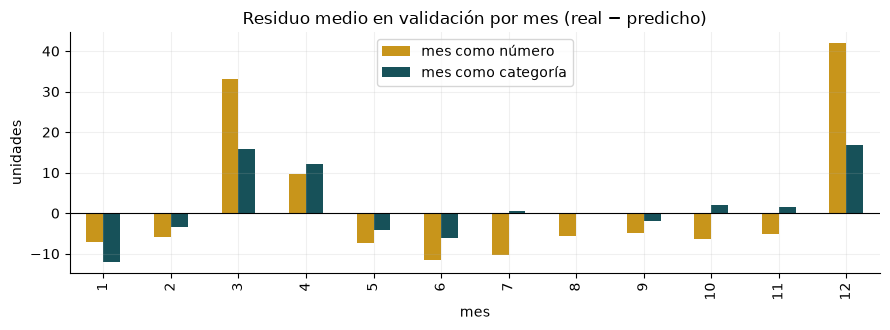

In [4]:
def ajustar_y_validar(mes_categorico):
    D_ent = matriz_diseno(Xe, mes_categorico)
    D_val = matriz_diseno(Xv, mes_categorico, columnas=D_ent.columns)
    modelo = LinearRegression().fit(D_ent, ye)
    return modelo, D_ent.columns, modelo.predict(D_val)


modelo_lineal, cols_lineal, pred_lineal = ajustar_y_validar(False)
modelo_estacional, cols_estacional, pred_estacional = ajustar_y_validar(True)
comparacion_mes = pd.DataFrame(
    {
        "mes como número": mr.metricas_regresion(yv, pred_lineal),
        "mes como categoría": mr.metricas_regresion(yv, pred_estacional),
    }
)
display(comparacion_mes)

residuo_por_mes = (
    pd.DataFrame(
        {
            "mes": Xv["mes"].values,
            "mes como número": yv.values - pred_lineal,
            "mes como categoría": yv.values - pred_estacional,
        }
    )
    .groupby("mes")
    .mean()
)
residuo_por_mes.plot(
    kind="bar",
    figsize=(9, 3.4),
    color=["#c8951b", "#175159"],
    title="Residuo medio en validación por mes (real − predicho)",
    ylabel="unidades",
)
plt.axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

**Lectura.** Con mes numérico, los residuos de noviembre y diciembre quedan positivos (el modelo predice de menos
justo cuando más se vende): un error caro para inventario. Las variables indicadoras de mes eliminan ese patrón y
bajan el error. Una variable bien representada vale más que un algoritmo más complejo.

<a id="diagnostico"></a>

## Diagnóstico de residuos

Un modelo útil deja residuos sin estructura: centrados en cero, de dispersión parecida en todo el rango de
predicción y sin colas extremas inesperadas. El gráfico cuantil–cuantil compara los residuos con una normal; la
normalidad importa para intervalos paramétricos, no para que el modelo prediga bien.

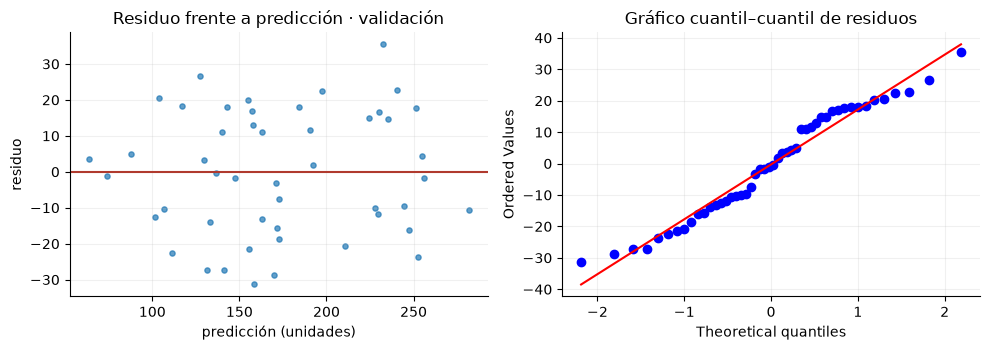

Media de residuos: -0.27 · desviación estándar: 17.25


In [5]:
residuos_val = yv.values - pred_estacional
fig, ejes = plt.subplots(1, 2, figsize=(10, 3.6))
ejes[0].scatter(pred_estacional, residuos_val, s=14, alpha=0.7)
ejes[0].axhline(0, color="#b03a2e")
ejes[0].set(
    xlabel="predicción (unidades)",
    ylabel="residuo",
    title="Residuo frente a predicción · validación",
)
stats.probplot(residuos_val, dist="norm", plot=ejes[1])
ejes[1].set_title("Gráfico cuantil–cuantil de residuos")
plt.tight_layout()
plt.show()
print(
    f"Media de residuos: {residuos_val.mean():.2f} · desviación estándar: {residuos_val.std(ddof=1):.2f}"
)

<a id="regularizacion"></a>

## Regularización: Ridge y Lasso (Semana 6)

Con muchas variables —meses, categorías e interacciones— los coeficientes de MCO se vuelven inestables. La
regularización agrega una penalización:

$$\text{Ridge: } \min_\beta \sum_i (y_i - x_i^\top\beta)^2 + \alpha\sum_j \beta_j^2 \qquad
\text{Lasso: } \min_\beta \tfrac{1}{2n}\sum_i (y_i - x_i^\top\beta)^2 + \alpha\sum_j |\beta_j|$$

Ridge encoge todos los coeficientes; Lasso puede llevar algunos exactamente a cero y selecciona variables. Las
variables se estandarizan dentro del pipeline para que la penalización trate igual a todas. El control cambia el
tipo y $\log_{10}\alpha$; las barras doradas indican coeficientes en cero.

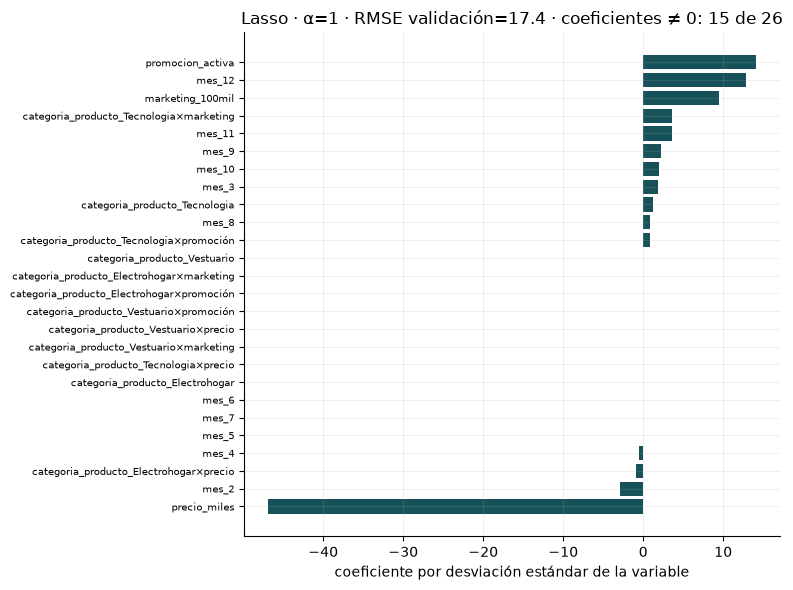

interactive(children=(Dropdown(description='tipo', options=('Lasso', 'Ridge'), value='Lasso'), FloatSlider(val…

<function __main__.explorar_regularizacion(tipo='Lasso', log10_alpha=0.0)>

In [6]:
def ampliar(marco, columnas=None):
    d = indicadores(marco, True, columnas is None)
    for c in [col for col in d.columns if col.startswith("categoria_producto_")]:
        d[c + "×promoción"] = d[c] * d["promocion_activa"]
        d[c + "×precio"] = d[c] * d["precio_miles"]
        d[c + "×marketing"] = d[c] * d["marketing_100mil"]
    return d if columnas is None else d.reindex(columns=columnas, fill_value=0.0)


Ae = ampliar(Xe)
Av = ampliar(Xv, columnas=Ae.columns)


def modelo_regularizado(tipo, alpha):
    estimador = Ridge(alpha=alpha) if tipo == "Ridge" else Lasso(alpha=alpha, max_iter=100_000)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        return Pipeline([("escalar", StandardScaler()), ("modelo", estimador)]).fit(Ae, ye)


def explorar_regularizacion(tipo="Lasso", log10_alpha=0.0):
    alpha = 10**log10_alpha
    m = modelo_regularizado(tipo, alpha)
    coef = pd.Series(m.named_steps["modelo"].coef_, index=Ae.columns).sort_values()
    rmse = mr.metricas_regresion(yv, m.predict(Av))["RMSE"]
    no_nulos = int((coef.abs() > 1e-8).sum())
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(coef.index, coef.values, color=np.where(coef.abs() < 1e-8, "#c8951b", "#175159"))
    ax.set(
        title=f"{tipo} · α={alpha:.3g} · RMSE validación={rmse:.1f} · coeficientes ≠ 0: {no_nulos} de {len(coef)}",
        xlabel="coeficiente por desviación estándar de la variable",
    )
    ax.tick_params(axis="y", labelsize=7)
    plt.tight_layout()
    plt.show()
    return {"alpha": alpha, "rmse_validacion": rmse, "no_nulos": no_nulos}


regularizacion_base = explorar_regularizacion()
widgets.interact(
    explorar_regularizacion,
    tipo=widgets.Dropdown(options=["Lasso", "Ridge"], value="Lasso"),
    log10_alpha=widgets.FloatSlider(value=0, min=-3, max=2.5, step=0.25, description="log10 α"),
)

El control ilustra sensibilidad; la elección formal de $\alpha$ usa **validación cruzada dentro de ajuste**.
`GridSearchCV` recibe el pipeline completo: en cada pliegue vuelve a aprender la escala y luego el modelo.
Poner `LassoCV` después de un escalador ya ajustado no reestima ese escalador en sus pliegues internos.
Una vez fijado alpha, la selección externa compara contra MCO; calibración y prueba siguen reservadas.

In [7]:
cv_interna = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)


def seleccionar_regularizacion(estimador, alphas):
    pipeline = Pipeline([("escalar", StandardScaler()), ("modelo", estimador)])
    return GridSearchCV(
        pipeline,
        {"modelo__alpha": alphas},
        cv=cv_interna,
        scoring="neg_root_mean_squared_error",
        n_jobs=1,
    ).fit(Ae, ye)


lasso_busqueda = seleccionar_regularizacion(Lasso(max_iter=100_000), np.logspace(-3, 2.5, 23))
ridge_busqueda = seleccionar_regularizacion(Ridge(), np.logspace(-3, 3, 31))
lasso_cv, ridge_cv = lasso_busqueda.best_estimator_, ridge_busqueda.best_estimator_
mco_ampliado = LinearRegression().fit(Ae, ye)
comparacion_reg = pd.DataFrame(
    {
        "MCO estacional": mr.metricas_regresion(yv, pred_estacional),
        "MCO ampliado": mr.metricas_regresion(yv, mco_ampliado.predict(Av)),
        "Ridge": mr.metricas_regresion(yv, ridge_cv.predict(Av)),
        "Lasso": mr.metricas_regresion(yv, lasso_cv.predict(Av)),
    }
).T
display(comparacion_reg)
display(
    pd.Series(
        {
            "alpha Ridge": ridge_busqueda.best_params_["modelo__alpha"],
            "alpha Lasso": lasso_busqueda.best_params_["modelo__alpha"],
        }
    )
)
print("Cada ajuste del escalador recibe solo el entrenamiento de su pliegue.")

,MAE,RMSE,R2,sesgo_medio,MAPE_%
MCO estacional,14.772,17.073,0.911,0.274,9.365
MCO ampliado,14.632,16.915,0.913,0.322,9.463
Ridge,14.339,16.627,0.916,0.312,9.289
Lasso,14.379,16.719,0.915,0.193,9.288


alpha Ridge       1
alpha Lasso   0.100
dtype: float64

Cada ajuste del escalador recibe solo el entrenamiento de su pliegue.


<a id="no-lineal"></a>

## Modelos no lineales y transferencia a otro caso

Un árbol de regresión parte el espacio en rectángulos y predice el promedio de cada uno; un bosque promedia muchos
árboles. Captan no linealidades sin especificarlas, a costa de interpretabilidad. Se comparan en validación con el
modelo estacional. Luego se transfiere el método a PulpaLenga, donde el consumo energético depende del tipo de
proceso: el pulpaje **mecánico** usa más electricidad que el **kraft**, que genera parte de su energía.

In [8]:
D_ent = matriz_diseno(Xe, True)
D_val = matriz_diseno(Xv, True, columnas=D_ent.columns)
arbol = DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=SEMILLA).fit(D_ent, ye)
bosque = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=5, random_state=SEMILLA, n_jobs=1
).fit(D_ent, ye)
display(
    pd.DataFrame(
        {
            "MCO estacional": mr.metricas_regresion(yv, pred_estacional),
            "Árbol de regresión": mr.metricas_regresion(yv, arbol.predict(D_val)),
            "Bosque aleatorio": mr.metricas_regresion(yv, bosque.predict(D_val)),
        }
    ).T
)

energia = mr.celulosa_energia()
Xen = pd.get_dummies(
    energia.drop(columns=["lote_id", "consumo_energetico_mwh"]), drop_first=True, dtype=float
)
yen = energia["consumo_energetico_mwh"]
Xen_e, Xen_v, Xen_t, yen_e, yen_v, yen_t = mr.particion_tres(Xen, yen, estratificar=False)
modelo_energia = LinearRegression().fit(Xen_e, yen_e)
display(pd.Series(modelo_energia.coef_, index=Xen.columns).round(2).to_frame("MWh por unidad"))
display(
    pd.Series(mr.metricas_regresion(yen_v, modelo_energia.predict(Xen_v))).to_frame(
        "energía · validación"
    )
)

,MAE,RMSE,R2,sesgo_medio,MAPE_%
MCO estacional,14.772,17.073,0.911,0.274,9.365
Árbol de regresión,21.256,27.888,0.764,6.326,14.157
Bosque aleatorio,17.499,22.006,0.853,2.766,11.733


,MWh por unidad
toneladas_producidas,0.960
temperatura_ambiente_c,-0.630
antiguedad_equipo_anios,2.860
tipo_proceso_Mecanico,87.350


,energía · validación
MAE,25.380
RMSE,32.181
R2,0.967
sesgo_medio,-4.218
MAPE_%,4.438


**Lectura.** En QuillayMarket la relación es casi lineal una vez modelada la estacionalidad: un modelo más complejo no
garantiza menor error. En PulpaLenga, a igual producción, el proceso mecánico consume del orden de 90 MWh más
por lote: una cifra que un gerente de planta entiende directamente.

<a id="escenarios"></a>

## Usar el modelo: intervalo conformal con calibración separada

Se conserva MCO con mes categórico como referencia interpretable para enseñar calibración. Ridge obtiene menor RMSE de selección en esta muestra; no se declara que MCO gana esa métrica. Esta elección didáctica queda fijada antes de consultar calibración y prueba. Se calculan residuos absolutos
**solo en las 48 réplicas de calibración**, sin volver a ajustar el modelo. Para nivel 80%, se toma
el residuo ordenado en la posición $k=\lceil(n_{cal}+1)0.8\rceil$ y se usa $\hat y\pm q$.
La garantía es marginal bajo intercambiabilidad; no garantiza cobertura por categoría ni extrapolaciones.
Si el tamaño no permite el nivel pedido, el intervalo conservador es infinito: no se recorta el rango artificialmente.


In [9]:
pred_calibracion = modelo_estacional.predict(matriz_diseno(Xcal, True, columnas=cols_estacional))
abs_residuos = np.abs(ycal.values - pred_calibracion)
nivel = 0.80
q_conformal = mr.cuantil_conformal(abs_residuos, nivel)
rango_precio = Xe.groupby("categoria_producto")["precio_promedio_clp"].agg(["min", "max"])


def explorar_escenario(
    categoria="Vestuario", mes=11, promocion=1, precio_miles=20.0, marketing_100mil=5.0
):
    fila = pd.DataFrame(
        [
            {
                "mes": mes,
                "categoria_producto": categoria,
                "precio_promedio_clp": precio_miles * 1000,
                "promocion_activa": promocion,
                "inversion_marketing_clp": marketing_100mil * 1e5,
            }
        ]
    )
    prediccion = float(
        modelo_estacional.predict(matriz_diseno(fila, True, columnas=cols_estacional))[0]
    )
    minimo, maximo = rango_precio.loc[categoria]
    aviso = (
        ""
        if minimo <= precio_miles * 1000 <= maximo
        else (
            f" ⚠ Precio fuera del rango observado para {categoria} ({minimo/1000:.1f}–{maximo/1000:.1f} miles): extrapolación."
        )
    )
    display(
        Markdown(
            f"**{categoria}, mes {mes}, promoción={promocion}:** {prediccion:.0f} unidades · intervalo "
            f"aproximado 80%: {max(0, prediccion - q_conformal):.0f}–{prediccion + q_conformal:.0f}.{aviso}"
        )
    )
    return {
        "prediccion": prediccion,
        "inferior": prediccion - q_conformal,
        "superior": prediccion + q_conformal,
    }


escenario_base = explorar_escenario()
widgets.interact(
    explorar_escenario,
    categoria=widgets.Dropdown(
        options=sorted(demanda["categoria_producto"].unique()), value="Vestuario"
    ),
    mes=widgets.IntSlider(value=11, min=1, max=12),
    promocion=widgets.Dropdown(options=[0, 1], value=1),
    precio_miles=widgets.FloatSlider(value=20, min=3, max=30, step=0.5),
    marketing_100mil=widgets.FloatSlider(value=5, min=0.5, max=9, step=0.5),
)

**Vestuario, mes 11, promoción=1:** 162 unidades · intervalo aproximado 80%: 144–181. ⚠ Precio fuera del rango observado para Vestuario (10.6–16.7 miles): extrapolación.

interactive(children=(Dropdown(description='categoria', index=3, options=('Alimentos', 'Electrohogar', 'Tecnol…

<function __main__.explorar_escenario(categoria='Vestuario', mes=11, promocion=1, precio_miles=20.0, marketing_100mil=5.0)>

<a id="evaluacion-final"></a>

## Evaluación final en prueba

El modelo y el cuantil permanecen congelados. Se consulta la prueba una vez y se informa
MAE, RMSE, sesgo y cobertura. No se reajusta con selección ni calibración después de calcular $q$.
La cobertura empírica tiene incertidumbre; no se usa para elegir de nuevo el nivel nominal.


In [10]:
modelo_final = modelo_estacional  # El mismo modelo que produjo los residuos de calibración.
pred_prueba = modelo_final.predict(matriz_diseno(Xt, True, columnas=cols_estacional))
informe_prueba = mr.metricas_regresion(yt, pred_prueba)
informe_prueba["cobertura_intervalo_80"] = float(
    np.mean(np.abs(yt.values - pred_prueba) <= q_conformal)
)
informe_prueba["semiancho_intervalo"] = q_conformal
display(pd.Series(informe_prueba).to_frame("prueba · modelo y calibración congelados"))
assert modelo_final is modelo_estacional
assert set(Xcal.index).isdisjoint(Xe.index) and set(Xcal.index).isdisjoint(Xv.index)

,prueba · modelo y calibración congelados
MAE,12.797
RMSE,15.991
R2,0.900
sesgo_medio,-0.967
MAPE_%,7.334
cobertura_intervalo_80,0.792
semiancho_intervalo,18.706


**Lectura crítica.** El 80% es una propiedad marginal del procedimiento bajo intercambiabilidad,
no una promesa para cada muestra ni para cada segmento. Con 96 casos de prueba, la cobertura observada fluctúa.
Reutilizar selección como calibración, reajustar el modelo después de calcular $q$ o retocar el nivel al ver
la prueba elimina la justificación de este procedimiento. Para comparar, dibuja ese flujo incorrecto y señala
qué información se reutiliza; no lo uses como evaluación final. CV+ y jackknife+ son procedimientos específicos,
no nombres para cualquier cuantil de residuos de validación cruzada.


### Ejercicios resueltos

1. **Interpretar.** Si el coeficiente de promoción es 55 con error estándar 3, un intervalo aproximado de 95% es
   $55 \pm 1{,}96 \cdot 3 \approx [49, 61]$ unidades, condicional al modelo. No es efecto causal sin diseño experimental.
2. **R² negativo.** En prueba, $R^2<0$ significa que el modelo predice peor que el promedio de la propia prueba.
   Puede ocurrir con extrapolación o deriva; no es un error de cálculo.
3. **Ridge frente a Lasso.** Con variables muy correlacionadas, Lasso elige una de forma inestable entre muestras;
   Ridge reparte el peso. Elastic Net combina ambos.
4. **Intervalo.** ¿Sirve el intervalo conformal para un precio fuera del rango? No: supone casos intercambiables con
   los de calibración; la extrapolación rompe ese supuesto.

In [11]:
auto_03 = pregunta(
    "¿Qué indica que Lasso deje varios coeficientes exactamente en cero?",
    [
        "Que esas variables no importan en ningún contexto",
        "Que con esa penalización el modelo prescinde de ellas para predecir; es selección condicional a α y a los datos",
        "Que hubo un error de convergencia",
    ],
    1,
    "La selección de Lasso depende de α, de la escala y de la correlación entre variables.",
)
fila_control = matriz_diseno(
    pd.DataFrame(
        [
            {
                "mes": 11,
                "categoria_producto": "Vestuario",
                "precio_promedio_clp": 20000,
                "promocion_activa": 1,
                "inversion_marketing_clp": 5e5,
            }
        ]
    ),
    True,
    columnas=cols_estacional,
)
assert (
    fila_control.loc[0, "categoria_producto_Vestuario"] == 1 and fila_control.loc[0, "mes_11"] == 1
)  # una fila conserva su categoría y mes
assert (
    comparacion_mes.loc["RMSE", "mes como categoría"]
    < comparacion_mes.loc["RMSE", "mes como número"]
)
assert tabla_mco.loc["promocion_activa", "coeficiente"] > 0
assert modelo_energia.coef_[list(Xen.columns).index("tipo_proceso_Mecanico")] > 50
assert 0 <= informe_prueba["cobertura_intervalo_80"] <= 1
print("Comprobaciones del laboratorio 03: OK")

Comprobaciones del laboratorio 03: OK


### Referencias

[James et al.: ISLP](https://www.statlearning.com/) (capítulos 3 y 6) ·
[scikit-learn: modelos lineales](https://scikit-learn.org/stable/modules/linear_model.html) ·
Angelopoulos y Bates, *A Gentle Introduction to Conformal Prediction* (2021), [arXiv:2107.07511](https://arxiv.org/abs/2107.07511).

## Práctica de transferencia 03

Con modelo congelado que predice 20 y residuos absolutos de calibración [1,2,3,4,5,6,7,8,9], calcula el intervalo conformal 80%. Identifica qué conjunto puede elegir alpha y qué cambia si reajustas después con calibración.

**Entrega:** hipótesis previa, cálculo con unidades, interpretación y límite. Completa tu respuesta antes de consultar la [pauta docente](../material_propio/PAUTA_DOCENTE.md#nb03).

**Discusión:** ¿Qué ocurre si se pide un nivel que el tamaño de calibración no permite?

### Tu resolución

Edita esta celda: escribe tu hipótesis, procedimiento, resultado, interpretación y una comprobación. Adjunta tu código o gráfico si la actividad lo requiere.

**Auto-revisión:** ¿usé la población correcta?, ¿declaré unidades y supuestos?, ¿mi evidencia permite esa conclusión?